# Feature Engineering
Builds `features_train.parquet` and `features_test.parquet` from the raw CSVs.

In [30]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA = 'data/'
TARGET = 'Electricity_balance_not_controllable'

train = pd.read_csv(DATA + 'train.csv', parse_dates=['date'])
test  = pd.read_csv(DATA + 'test.csv',  parse_dates=['date'])

train['date'] = train['date'].dt.tz_localize(None)
test['date']  = test['date'].dt.tz_localize(None)

print('train:', train.shape, '  test:', test.shape)

train: (137376, 24)   test: (17520, 20)


## Feature Engineering Function

In [31]:
def add_features(df, is_train=True, train_ref=None):
    """
    Adds time, trigonometric, interaction, and lag features.
    For test set, lags are filled from the end of train_ref.
    """
    df = df.copy()
    df = df.sort_values('date').reset_index(drop=True)

    # ── Trigonometric time encodings ──────────────────────────────────────────
    # day-of-year cycle (annual)
    doy = df['date'].dt.dayofyear
    df['sin_doy']  = np.sin(2 * np.pi * doy / 365.25)
    df['cos_doy']  = np.cos(2 * np.pi * doy / 365.25)

    # time-of-day cycle (daily, 48 slots)
    df['sin_tod']  = np.sin(2 * np.pi * df['tod'] / 48)
    df['cos_tod']  = np.cos(2 * np.pi * df['tod'] / 48)

    # week cycle
    df['sin_dow']  = np.sin(2 * np.pi * df['day_type_week'] / 7)
    df['cos_dow']  = np.cos(2 * np.pi * df['day_type_week'] / 7)

    # ── Temperature in Celsius ────────────────────────────────────────────────
    df['temp_c']   = df['temperature'] - 273.15
    df['temp_c2']  = df['temp_c'] ** 2   # U-shape heating/cooling effect

    # Heating / Cooling Degree (reference 15°C)
    df['hdd'] = np.maximum(15 - df['temp_c'], 0)
    df['cdd'] = np.maximum(df['temp_c'] - 22, 0)

    # ── Interaction features ──────────────────────────────────────────────────
    # Solar potential: low nebulosity at midday in summer → high generation
    df['solar_potential'] = (1 - df['nebulosity_by_solar_power_weights'] / 100) * df['cos_doy'].clip(0)
    df['solar_tod_inter'] = df['solar_potential'] * df['cos_tod'].clip(0)

    # Wind proxy
    df['wind_potential'] = df['wind_by_wind_power_weights'] ** 1.5  # cubic law approximation


    # ── Calendar dummies ──────────────────────────────────────────────────────
    # day_type_week_jf is already a combined workday/holiday flag — keep it
    # period_holiday, period_christmas, period_summer already present

    # Target lags won't work in this problem due to test set is a future period 
    #lag_source = pd.concat([train_ref[[TARGET, 'date']], df[[TARGET, 'date']]]) if not is_train else df

    """     for lag_hours in [24, 48, 168]:           # 1 day, 2 days, 1 week
        lag_slots = lag_hours * 2             # 30-min intervals
        col_name  = f'lag_{lag_hours}h'
        if is_train:
            df[col_name] = df[TARGET].shift(lag_slots)
        else:
            # For test rows, grab the lag value from combined series
            combined = pd.concat([
                train_ref[['date', TARGET]].set_index('date'),
                df[['date']].assign(**{TARGET: np.nan}).set_index('date')
            ]).sort_index()
            lag_vals = combined[TARGET].shift(lag_slots)
            df[col_name] = lag_vals.reindex(df['date'].values).values """

    """     # Rolling 24h stats on TARGET
    if is_train:
        df['roll_48_mean'] = df[TARGET].shift(2).rolling(48).mean()
        df['roll_48_std']  = df[TARGET].shift(2).rolling(48).std()
    else:
        combined = pd.concat([
            train_ref[['date', TARGET]].set_index('date'),
            df[['date']].assign(**{TARGET: np.nan}).set_index('date')
        ]).sort_index()[TARGET]
        df['roll_48_mean'] = combined.shift(2).rolling(48).mean().reindex(df['date'].values).values
        df['roll_48_std']  = combined.shift(2).rolling(48).std().reindex(df['date'].values).values """

    return df

print('Feature function defined.')

Feature function defined.


In [32]:
train_fe = add_features(train, is_train=True)
test_fe  = add_features(test,  is_train=False, train_ref=train)

print('Train feature set:', train_fe.shape)
print('Test  feature set:', test_fe.shape)


Train feature set: (137376, 37)
Test  feature set: (17520, 33)


In [33]:
# Feature columns to use for modelling
RAW_FEATS = [
    'month', 'year', 'tod', 'toy', 'week_number',
    'period_hour_changed', 'temperature', 'nebulosity', 'wind',
    'day_type_week', 'day_type_jf', 'day_type_week_jf',
    'period_holiday', 'period_christmas', 'period_summer',
    'nebulosity_by_solar_power_weights', 'wind_by_wind_power_weights',
]
ENG_FEATS = [
    'sin_doy','cos_doy','sin_tod','cos_tod','sin_dow','cos_dow',
    'temp_c','temp_c2','hdd','cdd',
    'solar_potential','solar_tod_inter','wind_potential',
    
]
FEATURES = RAW_FEATS + ENG_FEATS
print(f'Total features: {len(FEATURES)}')
print(FEATURES)

Total features: 30
['month', 'year', 'tod', 'toy', 'week_number', 'period_hour_changed', 'temperature', 'nebulosity', 'wind', 'day_type_week', 'day_type_jf', 'day_type_week_jf', 'period_holiday', 'period_christmas', 'period_summer', 'nebulosity_by_solar_power_weights', 'wind_by_wind_power_weights', 'sin_doy', 'cos_doy', 'sin_tod', 'cos_tod', 'sin_dow', 'cos_dow', 'temp_c', 'temp_c2', 'hdd', 'cdd', 'solar_potential', 'solar_tod_inter', 'wind_potential']


In [34]:
# Save to parquet for fast loading in the model notebook
train_fe.to_parquet('data/features_train.parquet', index=False)
test_fe.to_parquet('data/features_test.parquet', index=False)
print('Saved features_train.parquet and features_test.parquet')

# Also save the feature list
import json
with open('data/feature_list.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET}, f, indent=2)
print('Saved feature_list.json')

Saved features_train.parquet and features_test.parquet
Saved feature_list.json


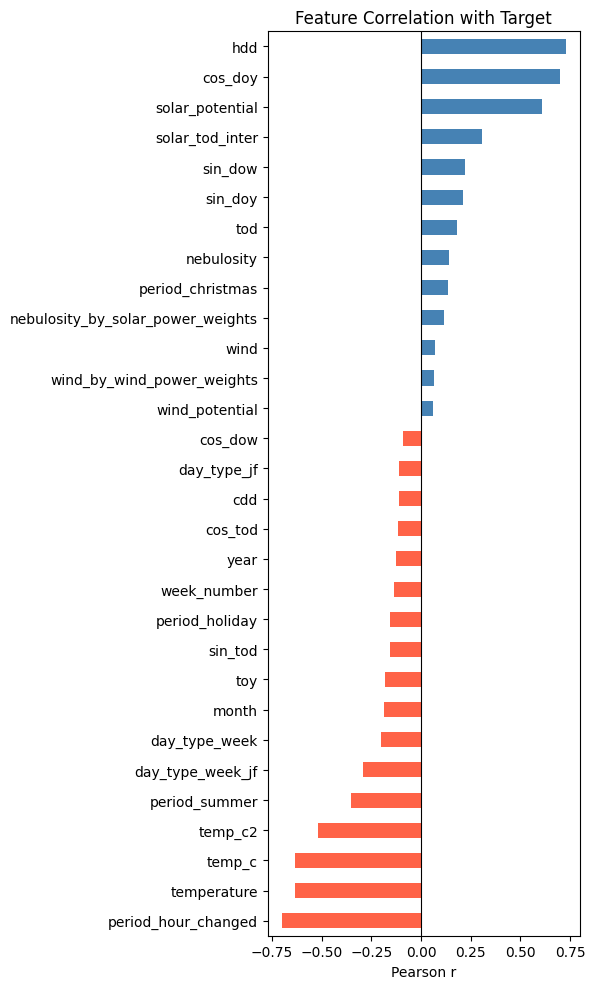

In [35]:
# Quick check: feature correlation with target
import matplotlib.pyplot as plt
import seaborn as sns

corrs = train_fe[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(6, 10))
colors = ['tomato' if v < 0 else 'steelblue' for v in corrs]
corrs.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Correlation with Target')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()